In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("All libraries imported successfully!")

All libraries imported successfully!


In [13]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Shape: {df.shape}")
print(f"Total Employees: {len(df)}")
print(f"\nAttrition Count:")
print(df['Attrition'].value_counts())
print(f"\nAttrition Rate: {(df['Attrition']=='Yes').mean()*100:.1f}%")
df.head()

Shape: (1470, 35)
Total Employees: 1470

Attrition Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [14]:
print("=== DATA QUALITY CHECK ===")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Total Columns: {len(df.columns)}")
print(f"\nNumerical Summary:")
print(df.describe().round(2))

=== DATA QUALITY CHECK ===
Missing Values: 0
Duplicate Rows: 0
Total Columns: 35

Numerical Summary:
           Age  DailyRate  DistanceFromHome  Education  EmployeeCount  \
count  1470.00    1470.00           1470.00    1470.00         1470.0   
mean     36.92     802.49              9.19       2.91            1.0   
std       9.14     403.51              8.11       1.02            0.0   
min      18.00     102.00              1.00       1.00            1.0   
25%      30.00     465.00              2.00       2.00            1.0   
50%      36.00     802.00              7.00       3.00            1.0   
75%      43.00    1157.00             14.00       4.00            1.0   
max      60.00    1499.00             29.00       5.00            1.0   

       EmployeeNumber  EnvironmentSatisfaction  HourlyRate  JobInvolvement  \
count         1470.00                  1470.00     1470.00         1470.00   
mean          1024.87                     2.72       65.89            2.73   
std    

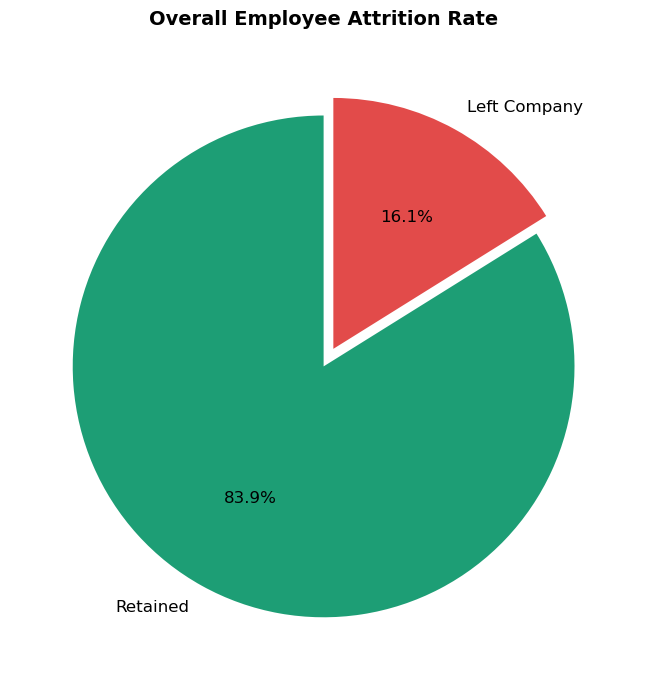

Employees who left: 237
Employees retained: 1233
Attrition Rate: 16.1%


In [15]:
plt.figure(figsize=(7, 7))
attrition_count = df['Attrition'].value_counts()
colors = ['#1D9E75', '#E24B4A']
plt.pie(attrition_count.values,
        labels=['Retained', 'Left Company'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=(0, 0.08),
        textprops={'fontsize': 12})
plt.title('Overall Employee Attrition Rate',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart1_attrition_rate.png', dpi=150)
plt.show()
print(f"Employees who left: {(df['Attrition']=='Yes').sum()}")
print(f"Employees retained: {(df['Attrition']=='No').sum()}")
print(f"Attrition Rate: {(df['Attrition']=='Yes').mean()*100:.1f}%")

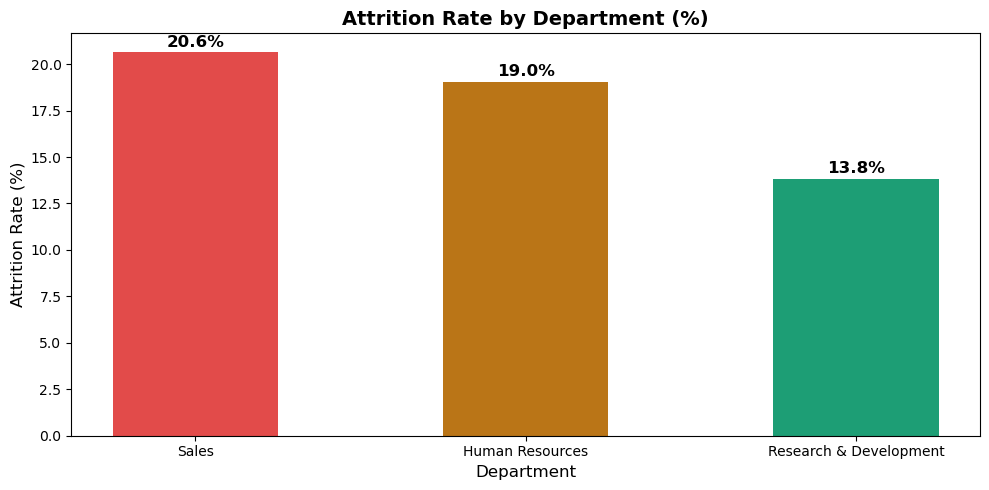

Highest Attrition: Sales (20.6%)
Lowest Attrition: Research & Development (13.8%)


In [16]:
plt.figure(figsize=(10, 5))
dept_attr = df.groupby('Department')['Attrition']\
              .apply(lambda x: (x=='Yes').mean()*100)\
              .sort_values(ascending=False)
colors = ['#E24B4A', '#BA7517', '#1D9E75']
bars = plt.bar(dept_attr.index, dept_attr.values,
               color=colors, width=0.5)
plt.title('Attrition Rate by Department (%)',
          fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
for bar, val in zip(bars, dept_attr.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_dept_attrition.png', dpi=150)
plt.show()
print(f"Highest Attrition: {dept_attr.idxmax()} ({dept_attr.max():.1f}%)")
print(f"Lowest Attrition: {dept_attr.idxmin()} ({dept_attr.min():.1f}%)")

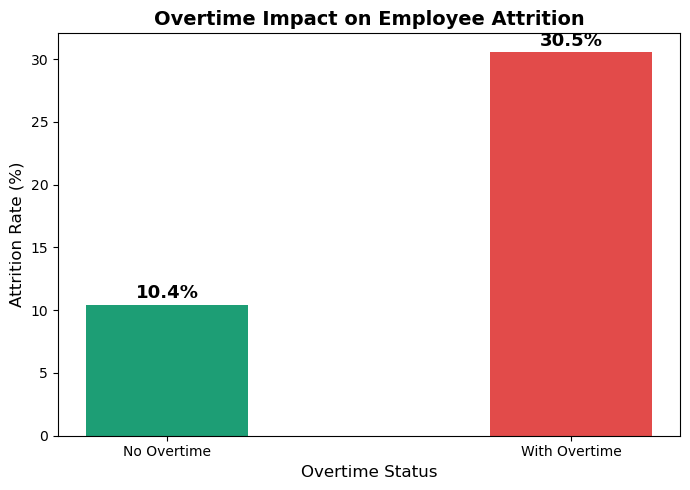

Overtime Attrition: 30.5%
No Overtime Attrition: 10.4%


In [17]:
plt.figure(figsize=(7, 5))
ot_attr = df.groupby('OverTime')['Attrition']\
            .apply(lambda x: (x=='Yes').mean()*100)
colors = ['#1D9E75', '#E24B4A']
bars = plt.bar(['No Overtime', 'With Overtime'],
               ot_attr.values,
               color=colors, width=0.4)
plt.title('Overtime Impact on Employee Attrition',
          fontsize=14, fontweight='bold')
plt.xlabel('Overtime Status', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
for bar, val in zip(bars, ot_attr.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_overtime_attrition.png', dpi=150)
plt.show()
print(f"Overtime Attrition: {ot_attr['Yes']:.1f}%")
print(f"No Overtime Attrition: {ot_attr['No']:.1f}%")

/tmp/ipykernel_144/491089965.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([attr_yes, attr_no],


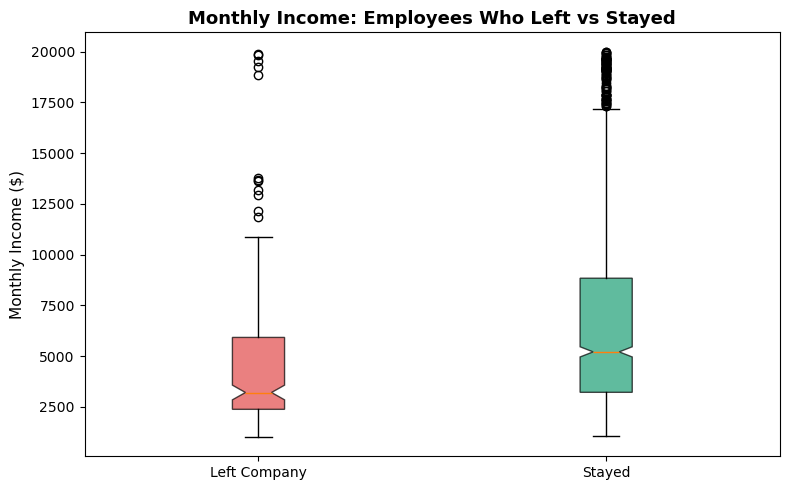

Avg Income (Left): $4,787
Avg Income (Stayed): $6,833
Difference: $2,046


In [18]:
plt.figure(figsize=(8, 5))
attr_yes = df[df['Attrition']=='Yes']['MonthlyIncome']
attr_no = df[df['Attrition']=='No']['MonthlyIncome']
bp = plt.boxplot([attr_yes, attr_no],
                 labels=['Left Company', 'Stayed'],
                 patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('#E24B4A')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#1D9E75')
bp['boxes'][1].set_alpha(0.7)
plt.title('Monthly Income: Employees Who Left vs Stayed',
          fontsize=13, fontweight='bold')
plt.ylabel('Monthly Income ($)', fontsize=11)
plt.tight_layout()
plt.savefig('chart4_income_boxplot.png', dpi=150)
plt.show()
print(f"Avg Income (Left): ${attr_yes.mean():,.0f}")
print(f"Avg Income (Stayed): ${attr_no.mean():,.0f}")
print(f"Difference: ${attr_no.mean()-attr_yes.mean():,.0f}")

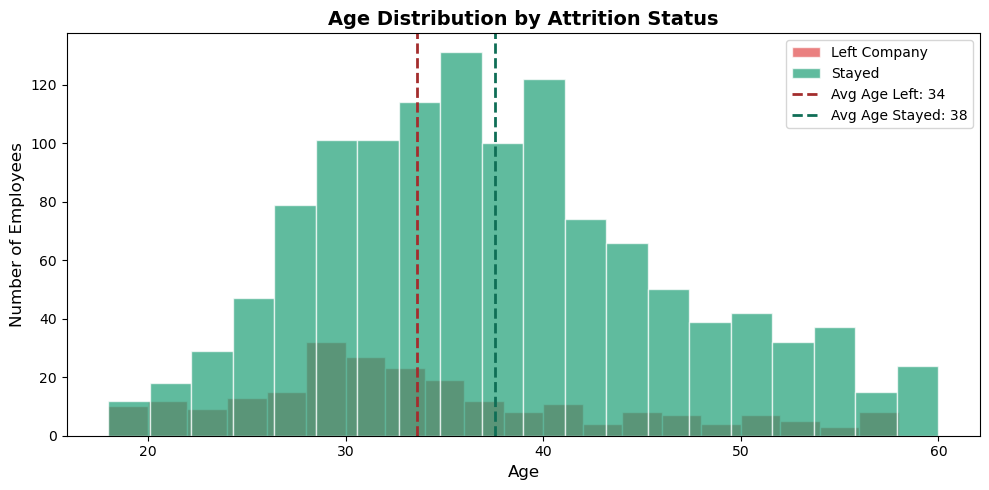

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(df[df['Attrition']=='Yes']['Age'],
         bins=20, alpha=0.7, color='#E24B4A',
         label='Left Company', edgecolor='white')
plt.hist(df[df['Attrition']=='No']['Age'],
         bins=20, alpha=0.7, color='#1D9E75',
         label='Stayed', edgecolor='white')
avg_yes = df[df['Attrition']=='Yes']['Age'].mean()
avg_no = df[df['Attrition']=='No']['Age'].mean()
plt.axvline(avg_yes, color='#A32D2D',
            linestyle='--', linewidth=2,
            label=f'Avg Age Left: {avg_yes:.0f}')
plt.axvline(avg_no, color='#0F6E56',
            linestyle='--', linewidth=2,
            label=f'Avg Age Stayed: {avg_no:.0f}')
plt.title('Age Distribution by Attrition Status',
          fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('chart5_age_distribution.png', dpi=150)
plt.show()

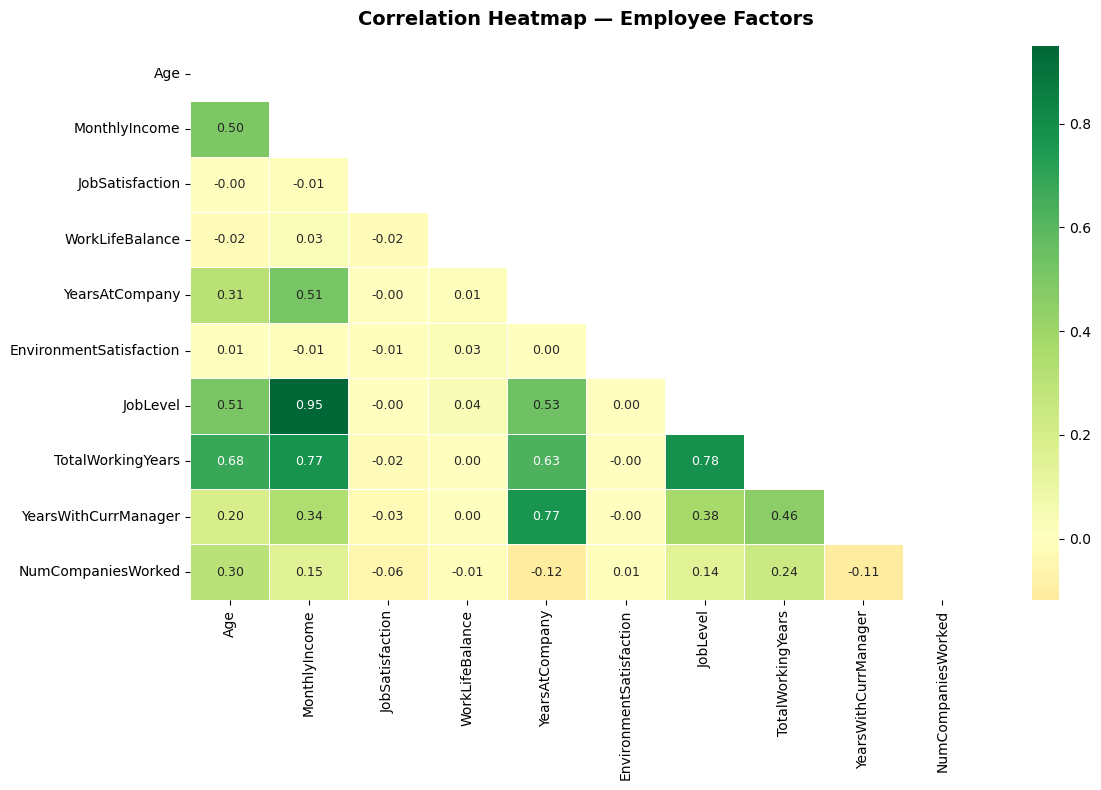

In [20]:
numerical_cols = ['Age', 'MonthlyIncome',
                  'JobSatisfaction', 'WorkLifeBalance',
                  'YearsAtCompany', 'EnvironmentSatisfaction',
                  'JobLevel', 'TotalWorkingYears',
                  'YearsWithCurrManager', 'NumCompaniesWorked']
plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', mask=mask, center=0,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap — Employee Factors',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart6_correlation_heatmap.png', dpi=150)
plt.show()

In [21]:
print("=" * 55)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 55)

tests = [
    ('Monthly Income', 'MonthlyIncome'),
    ('Age', 'Age'),
    ('Years at Company', 'YearsAtCompany'),
    ('Job Satisfaction', 'JobSatisfaction'),
]

for name, col in tests:
    yes = df[df['Attrition']=='Yes'][col]
    no = df[df['Attrition']=='No'][col]
    t, p = stats.ttest_ind(yes, no)
    result = 'SIGNIFICANT ✓' if p < 0.05 else 'Not significant'
    print(f"\n{name}:")
    print(f"  Left: {yes.mean():.2f} | Stayed: {no.mean():.2f}")
    print(f"  P-value: {p:.4f} → {result}")

print("=" * 55)

STATISTICAL SIGNIFICANCE TESTS

Monthly Income:
  Left: 4787.09 | Stayed: 6832.74
  P-value: 0.0000 → SIGNIFICANT ✓

Age:
  Left: 33.61 | Stayed: 37.56
  P-value: 0.0000 → SIGNIFICANT ✓

Years at Company:
  Left: 5.13 | Stayed: 7.37
  P-value: 0.0000 → SIGNIFICANT ✓

Job Satisfaction:
  Left: 2.47 | Stayed: 2.78
  P-value: 0.0001 → SIGNIFICANT ✓


In [22]:
print("=" * 55)
print("   HR ATTRITION — FINAL KEY FINDINGS")
print("=" * 55)
print(f"Total Employees    : {len(df):,}")
print(f"Attrition Rate     : "
      f"{(df['Attrition']=='Yes').mean()*100:.1f}%")
dept = df.groupby('Department')['Attrition']\
         .apply(lambda x: (x=='Yes').mean()*100)
print(f"Worst Dept         : {dept.idxmax()} "
      f"({dept.max():.1f}%)")
ot = df.groupby('OverTime')['Attrition']\
       .apply(lambda x: (x=='Yes').mean()*100)
print(f"Overtime Attrition : {ot.get('Yes', 0):.1f}%")
print(f"Avg Age (Left)     : "
      f"{df[df['Attrition']=='Yes']['Age'].mean():.1f}")
print(f"Avg Income (Left)  : "
      f"${df[df['Attrition']=='Yes']['MonthlyIncome'].mean():,.0f}")
print(f"Avg Income (Stayed): "
      f"${df[df['Attrition']=='No']['MonthlyIncome'].mean():,.0f}")
print("=" * 55)
print("Python EDA COMPLETE!")

   HR ATTRITION — FINAL KEY FINDINGS
Total Employees    : 1,470
Attrition Rate     : 16.1%
Worst Dept         : Sales (20.6%)
Overtime Attrition : 30.5%
Avg Age (Left)     : 33.6
Avg Income (Left)  : $4,787
Avg Income (Stayed): $6,833
Python EDA COMPLETE!
